<a href="https://colab.research.google.com/github/renanprs1/Atividade-pr-tica-Matplotlib/blob/main/Projeto%20Refer%C3%AAncia%20G2%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sqlalchemy import create_engine

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [4]:
df = pd.read_csv("/content/sample_data/vendas_brasil.csv")

df.head()

,data,uf,canal,categoria,segmento,produto,quantidade,receita,custo,lucro
0,2023-01-01 00:00:00.000000000,BA,Online,Acessórios,Corporativo,Produto_40,1,2133.016905,1515.430447,617.586458
1,2023-01-01 07:00:38.895558223,BA,Loja Física,Acessórios,Corporativo,Produto_27,13,18812.079172,15735.396787,3076.682385
2,2023-01-01 07:00:38.895558223,BA,Online,Eletrônicos,Distribuidor,Produto_108,1,666.417476,483.318288,183.099188
3,2023-01-01 14:01:17.791116446,PR,Online,Informática,Corporativo,Produto_51,9,6616.534025,5587.961806,1028.572218
4,2023-01-02 18:03:53.373349339,MG,Marketplace,Informática,Corporativo,Produto_3,2,4544.174036,2797.938769,1746.235267


In [5]:
print("Dimensões da base:", df.shape)
print("\nTipos de dados:")
print(df.dtypes)

print("\nValores ausentes:")
print(df.isnull().sum())

print("\nDuplicidades:")
print(df.duplicated().sum())

Dimensões da base: (2500, 10)

Tipos de dados:
data           object
uf             object
canal          object
categoria      object
segmento       object
produto        object
quantidade      int64
receita       float64
custo         float64
lucro         float64
dtype: object

Valores ausentes:
data          0
uf            0
canal         0
categoria     0
segmento      0
produto       0
quantidade    0
receita       0
custo         0
lucro         0
dtype: int64

Duplicidades:
0


In [6]:
df["data"] = pd.to_datetime(df["data"], errors="coerce")

df["ano"] = df["data"].dt.year
df["mes"] = df["data"].dt.month
df["ano_mes"] = df["data"].dt.to_period("M").astype(str)

df["margem_lucro"] = df["lucro"] / df["receita"]
df["ticket_medio"] = df["receita"] / df["quantidade"]

df.head()

,data,uf,canal,categoria,segmento,produto,quantidade,receita,custo,lucro,ano,mes,ano_mes,margem_lucro,ticket_medio
0,2023-01-01 00:00:00.000000000,BA,Online,Acessórios,Corporativo,Produto_40,1,2133.016905,1515.430447,617.586458,2023,1,2023-01,0.289537,2133.016905
1,2023-01-01 07:00:38.895558223,BA,Loja Física,Acessórios,Corporativo,Produto_27,13,18812.079172,15735.396787,3076.682385,2023,1,2023-01,0.163548,1447.083013
2,2023-01-01 07:00:38.895558223,BA,Online,Eletrônicos,Distribuidor,Produto_108,1,666.417476,483.318288,183.099188,2023,1,2023-01,0.274751,666.417476
3,2023-01-01 14:01:17.791116446,PR,Online,Informática,Corporativo,Produto_51,9,6616.534025,5587.961806,1028.572218,2023,1,2023-01,0.155455,735.170447
4,2023-01-02 18:03:53.373349339,MG,Marketplace,Informática,Corporativo,Produto_3,2,4544.174036,2797.938769,1746.235267,2023,1,2023-01,0.384280,2272.087018


In [7]:
receita_total = df["receita"].sum()
lucro_total = df["lucro"].sum()
margem_lucro = lucro_total / receita_total
ticket_medio = df["receita"].sum() / df["quantidade"].sum()
quantidade_total = df["quantidade"].sum()

print(f"Receita total: R$ {receita_total:,.2f}")
print(f"Lucro total: R$ {lucro_total:,.2f}")
print(f"Margem de lucro: {margem_lucro:.2%}")
print(f"Ticket médio: R$ {ticket_medio:,.2f}")
print(f"Quantidade vendida: {quantidade_total:,.0f}")

Receita total: R$ 23,447,433.28
Lucro total: R$ 6,991,626.28
Margem de lucro: 29.82%
Ticket médio: R$ 1,258.11
Quantidade vendida: 18,637


In [8]:
serie_mensal = (
    df.groupby("ano_mes")[["receita", "lucro"]]
    .sum()
    .reset_index()
    .sort_values("ano_mes")
)

serie_mensal.head()

,ano_mes,receita,lucro
0,2023-01,775635.146185,227131.790126
1,2023-02,990851.886978,305128.214503
2,2023-03,977880.786932,316900.450099
3,2023-04,933701.373850,275066.245084
4,2023-05,971757.628787,281637.067036


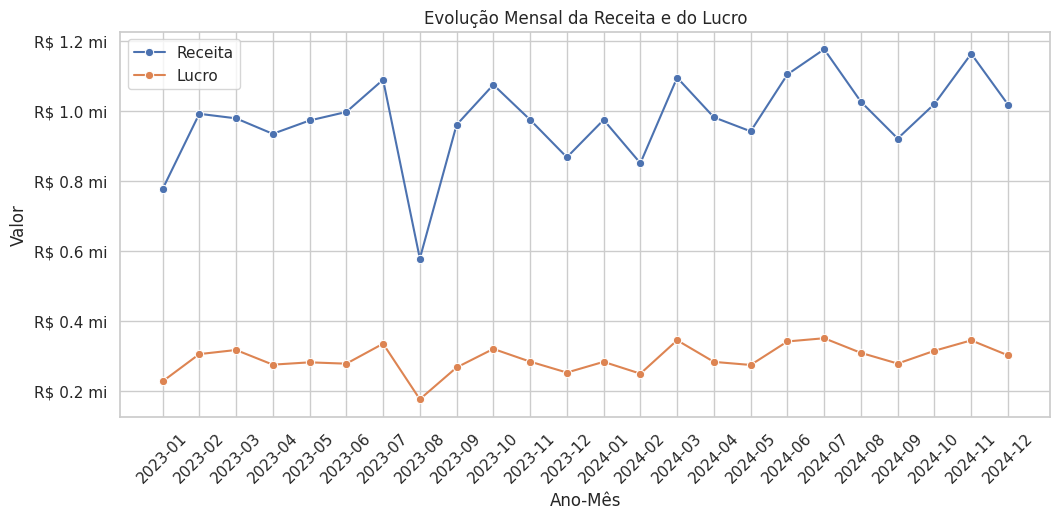

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(data=serie_mensal, x="ano_mes", y="receita", marker="o", label="Receita", ax=ax)
sns.lineplot(data=serie_mensal, x="ano_mes", y="lucro", marker="o", label="Lucro", ax=ax)

ax.set_title("Evolução Mensal da Receita e do Lucro")
ax.set_xlabel("Ano-Mês")
ax.set_ylabel("Valor")
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'R$ {x/1_000_000:.1f} mi')
)

ax.tick_params(axis="x", rotation=45)
plt.show()

In [10]:
pd.options.display.float_format = '{:.2f}'.format
desempenho_canal = (
    df.groupby("canal")
    .agg(
        receita_total=("receita", "sum"),
        lucro_total=("lucro", "sum"),
        quantidade_total=("quantidade", "sum")
    )
    .reset_index()
)

desempenho_canal["margem_lucro"] = desempenho_canal["lucro_total"] / desempenho_canal["receita_total"]

desempenho_canal.sort_values("receita_total", ascending=False)

,canal,receita_total,lucro_total,quantidade_total,margem_lucro
0,Loja Física,6527690.62,1915973.79,5276,0.29
2,Online,6091973.33,1835425.28,4790,0.30
1,Marketplace,5729896.54,1698460.83,4334,0.30
3,Representante,5097872.79,1541766.39,4237,0.30


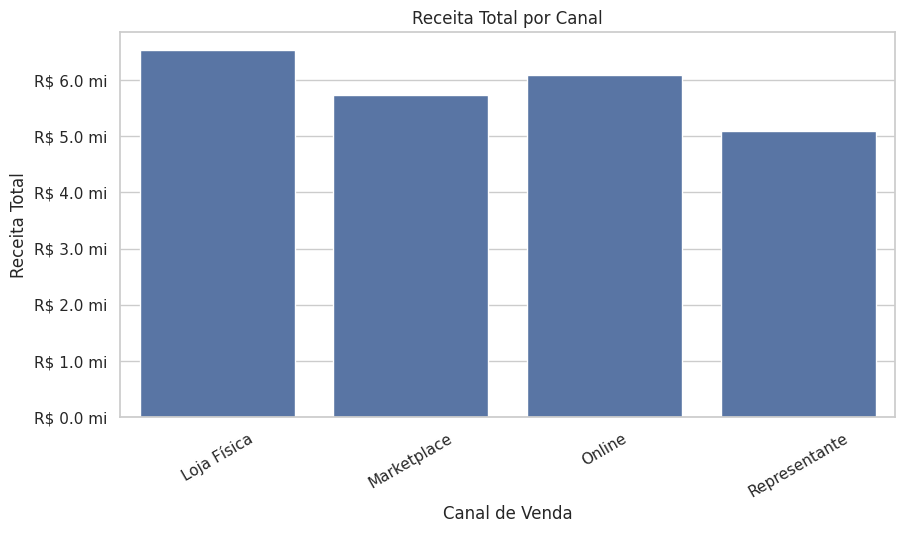

In [11]:
# Criação do gráfico
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=desempenho_canal,
    x="canal",
    y="receita_total",
    ax=ax
)

# Títulos e rótulos
ax.set_title("Receita Total por Canal")
ax.set_xlabel("Canal de Venda")
ax.set_ylabel("Receita Total")

# Formatação do eixo Y
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'R$ {x/1_000_000:.1f} mi')
)

# Rotação dos rótulos
ax.tick_params(axis="x", rotation=30)

plt.show()

In [12]:
receita_categoria = (
    df.groupby("categoria")["receita"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

receita_categoria

,categoria,receita
0,Eletrônicos,5003914.59
1,Móveis,4835447.27
2,Informática,4833342.00
3,Acessórios,4392160.76
4,Serviços,4382568.66


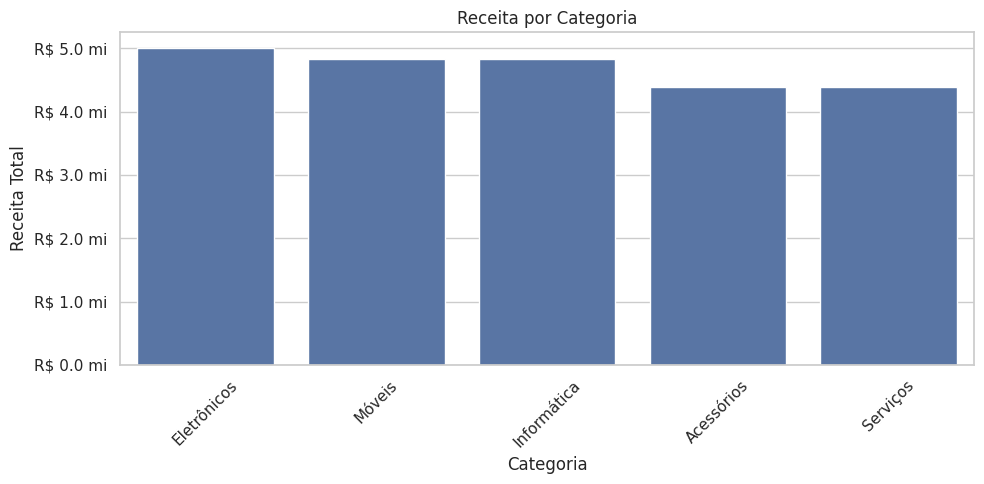

In [13]:
# Criação da figura
fig, ax = plt.subplots(figsize=(10, 5))

# Gráfico
sns.barplot(
    data=receita_categoria,
    x="categoria",
    y="receita",
    ax=ax
)

# Títulos
ax.set_title("Receita por Categoria")
ax.set_xlabel("Categoria")
ax.set_ylabel("Receita Total")

# Formatação do eixo Y
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'R$ {x/1_000_000:.1f} mi')
)

# Rotação do eixo X
plt.xticks(rotation=45)

# Ajuste do layout
plt.tight_layout()

# Exibição
plt.show()

In [14]:
receita_uf = (
    df.groupby("uf")["receita"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

receita_uf.head()

,uf,receita
0,SC,3225001.89
1,ES,3116278.98
2,PR,3072631.61
3,RS,3022015.85
4,MG,2845556.14


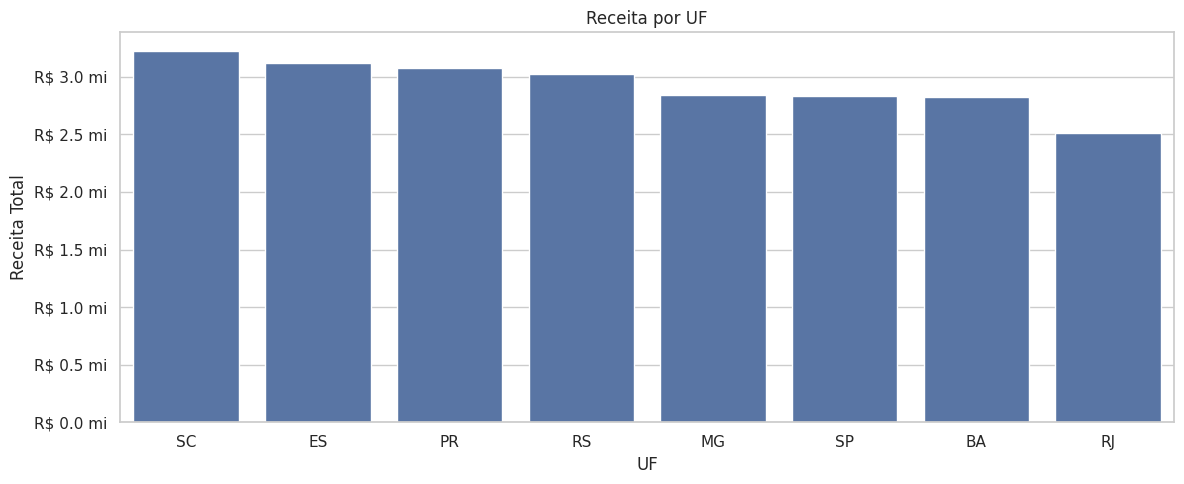

In [15]:
# Criação da figura
fig, ax = plt.subplots(figsize=(12, 5))

# Gráfico
sns.barplot(
    data=receita_uf,
    x="uf",
    y="receita",
    ax=ax
)

# Títulos
ax.set_title("Receita por UF")
ax.set_xlabel("UF")
ax.set_ylabel("Receita Total")

# Formatação do eixo Y
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'R$ {x/1_000_000:.1f} mi')
)

# Melhorias visuais
plt.xticks(rotation=0)
plt.tight_layout()

# Exibição
plt.show()

In [17]:
engine = create_engine("sqlite:////content/vendas_brasil.sqlite")

df.to_sql("vendas", engine, if_exists="replace", index=False)

print("Tabela vendas criada no banco SQLite.")

Tabela vendas criada no banco SQLite.


In [18]:
consulta = '''
SELECT canal,
       SUM(receita) AS receita_total,
       SUM(lucro) AS lucro_total,
       SUM(lucro) / SUM(receita) AS margem_lucro
FROM vendas
GROUP BY canal
ORDER BY receita_total DESC
'''

pd.read_sql(consulta, engine)

,canal,receita_total,lucro_total,margem_lucro
0,Loja Física,6527690.62,1915973.79,0.29
1,Online,6091973.33,1835425.28,0.30
2,Marketplace,5729896.54,1698460.83,0.30
3,Representante,5097872.79,1541766.39,0.30
